In [1]:
import yfinance as yf
from finta import TA
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import yahoo_fin.stock_info as si
import matplotlib.pyplot as plt

# from sklearn.linear_model import LinearRegression
# from sklearn.metrics.pairwise import euclidean_distances
# from sklearn.cluster import DBSCAN

from collections import OrderedDict
import pandas as pd
from functools import reduce
import random
import glob
import warnings
warnings.filterwarnings("ignore")

In [ ]:
random_number = random.randint(0,16777215)
hex_number = str(hex(random_number))[2:].zfill(6)
hex_number

In [ ]:
def get_hex_color():
    random_number = random.randint(0,16777215)
    hex_number = str(hex(random_number))[2:].zfill(6)
    
    
    
    hex_number ='#'+ hex_number
    return hex_number

def generate_colors_by_indicator(cols_indicadores):
    colors_by_indicador = {}
    
    for c in cols_indicadores:
        colors_by_indicador[c] = get_hex_color()
    
    return colors_by_indicador

In [ ]:
def compute_indicators(df,indicators):
    """
    Function to compute indicators. 
    
    NOTE: You could add more indicators.
    """

    cols_names = []

    if indicators.get("KAMA",[]):
        kama = indicators.get("KAMA")

        for period in kama:
            kama_values = TA.KAMA(df,period).tolist()

            col_name = "kama_{}".format(str(period))
            df[col_name] = kama_values

            cols_names.append(col_name)
            
    if indicators.get("EMA",[]):
        ema = indicators.get("EMA")

        for period in ema:
            ema_values = TA.EMA(df,period).tolist()

            col_name = "ema_{}".format(str(period))
            df[col_name] = ema_values

            cols_names.append(col_name)
            
    if indicators.get('RSI',[]):
        rsi = indicators.get('RSI')
        
        for period in rsi:
            rsi_values = TA.RSI(df,period)
            
            col_name = "rsi_{}".format(str(period))
            df[col_name] = rsi_values
            
            cols_names.append(col_name)
        
        
    return df,cols_names

In [ ]:
def normalize_values(df,col,scale=3):
    max_val = df[col].max()
    df[col] = scale*df[col]/max_val
    return df

def select_floor_ceiling_mode(mode, selection_values):
    
    g_value,l_value = selection_values
    
    if mode == 'kama':
        g_col = "kama_{}".format(g_value)
        l_col = "kama_{}".format(l_value)
    
    elif mode == 'ema':
        g_col = "ema_{}".format(g_value)
        l_col = "ema_{}".format(l_value)
    
    return g_col,l_col

def find_max_min_values(data):
    floor_ceil = data.floor_ceil.tolist()

    val_min = [np.inf,"",""]
    val_max = [-np.inf,"",""]
    all_values = []
  
    for indx,_ in enumerate(floor_ceil):
        
        if indx==0:
            continue

        if floor_ceil[indx]==floor_ceil[indx-1]:
            if floor_ceil[indx] == 1:
                if val_max[0] <= data.loc[indx,"High"]:
                    val_max[0] = data.loc[indx,"High"]
                    val_max[1] = data.loc[indx,"Date"]
                    val_max[2] = "Max"
            else:
                if val_min[0] >= data.loc[indx,"Low"]:
                    val_min[0] = data.loc[indx,"Low"]
                    val_min[1] = data.loc[indx,"Date"]
                    val_min[2] = "Min"
        else:
            all_values.append(val_max)
            all_values.append(val_min)

            val_min = [np.inf,"",""]
            val_max = [-np.inf,"",""]

            if floor_ceil[indx] == 1:
                if val_max[0] <= data.loc[indx,"High"]:
                    val_max[0] = data.loc[indx,"High"]
                    val_max[1] = data.loc[indx,"Date"]
                    val_max[2] = "Max"
            else:
                if val_min[0] >= data.loc[indx,"Low"]:
                    val_min[0] = data.loc[indx,"Low"]
                    val_min[1] = data.loc[indx,"Date"]
                    val_min[2] = "Min"
            
    
    df = pd.DataFrame(all_values)
    df.columns = ['value','dates','move']
    df = df[df.move != ""]
    
    return df

def cluster_floor_ceiling(floor_ceil,pt=5):
    
    val_min = floor_ceil.value - floor_ceil.value.min()
    range_ = floor_ceil.value.max() - floor_ceil.value.min()
    
    floor_ceil['value_st'] = val_min/range_ 
    floor_ceil['value_st_2'] = 1
    
    dist_eu = euclidean_distances(floor_ceil[['value_st','value_st_2']])
    vals = [np.round(e,3) for e in list(dist_eu.flatten()) if e > 0]
    e = np.percentile(vals,pt)
    print("Distance :",e)

    db = DBSCAN(eps=e, min_samples=2).fit(floor_ceil[['value_st','value_st_2']])
    floor_ceil['classification'] = db.labels_

    df_class = floor_ceil[floor_ceil.classification!=-1]\
                        .groupby('classification')\
                        .agg({'value':['mean','count'],
                              'dates':'first'}).reset_index()
    df_class.columns = ['classification','value','num_vals','dates']
    
    df_without_class = floor_ceil.loc[floor_ceil.classification==-1,
                                      ['classification','value','dates']]
    df_without_class['num_vals'] = 1
    
    floor_ceil = pd.concat([df_without_class,
                            df_class])
    
    ini_lines = floor_ceil.shape[0]
    print("ratio lines: ", 100*floor_ceil.shape[0]/ini_lines)
    
    return floor_ceil

def detect_crossings(df,mode, selection_values):
    
    g_col,l_col = select_floor_ceiling_mode(mode, selection_values)
    
    # Detect when g_value crosses l_value and viceversa
    df['floor_ceil'] = [1 if row[g_col] <= row[l_col] else -1 
                                for _,row in df[[g_col,l_col]].iterrows()]
    return df

def compute_floors_ceilings(df,selection_values,mode='kama'):
    
    df = detect_crossings(df,mode, selection_values)

    floor_ceil = find_max_min_values(df)

    if floor_ceil.empty:
        return floor_ceil
    
    else:
        floor_ceil = floor_ceil[~floor_ceil.dates.isna()]
            
    floor_ceil = cluster_floor_ceiling(floor_ceil.copy())
    
    floor_ceil = normalize_values(floor_ceil,'num_vals')
          
    return floor_ceil

FIBOS_RATIOS = [0,0.236,0.382,0.50,0.618,0.764,1]

def compute_fibonacci(df,selection_values,mode='kama'):
    
    df = detect_crossings(df,mode, selection_values)
    
    df = find_max_min_values(df)
    
    df.reset_index(drop=True,inplace=True)
    
    fibos = pd.DataFrame(columns=['value','dates','move'])

    for indx, _ in df.iterrows():

        if indx == 0:
            continue

        range_vals = [df.loc[indx].value,
                      df.loc[indx-1].value]

        max_val = max(range_vals)
        min_val = min(range_vals)
        range_ = max_val - min_val
        date = df.loc[indx].dates

        for fibo_val in FIBOS_RATIOS:
            new_fibo = {'value':min_val + fibo_val*range_,
                        'dates':date,
                        'move':str(fibo_val)}
            fibos = fibos.append(new_fibo,ignore_index=True)
    
    fibos = cluster_floor_ceiling(fibos.copy())
    
    fibos = normalize_values(fibos,'num_vals')
    
    return fibos

In [7]:
def impute_values(df):
    # Fill NA's with previous 
    df = df.fillna(method='ffill')
    return df

def clean_data(data,tk):

    open = data["Open"][tk].rename("Open").reset_index()
    close = data["Close"][tk].rename("Close").reset_index()
    high = data["High"][tk].rename("High").reset_index()
    low = data["Low"][tk].rename("Low").reset_index()
    volume = data["Volume"][tk].rename("Volume").reset_index()
  
    func = lambda x,y: x.merge(y,on='Date',how='left')
  
    # Merge all dataframes
    df = reduce(func,[open,close,high,low,volume])
    
    # Impute values
    df = impute_values(df)
    
    return df
    

In [ ]:

def compute_profit(df,strategy,from_,to_,date_col="Date",num_shares=1):
    
    if from_ > to_:
        raise("Incorrect dates")
    
    data = df[(df[date_col]>=from_)&(df[date_col]<=to_)]
    
    dates_list = data[date_col].sort_values().tolist()
    
    shares = 0
    ini_mount = 0
    mount = 0
    
    for indx,date in enumerate(dates_list[:-1]):
        move = strategy(data,date)
        
        if shares == 0:
            
            if move == "buy":
                # Buy share the next day
                buy_at = data.loc[data[date_col]==dates_list[indx + 1],"Open"].values[0]
                print("Date: ",date,"Buy: ",buy_at)
                
                if ini_mount == 0:
                    ini_mount = buy_at
                    mount = -1*buy_at
                else:
                    mount = mount - buy_at
                shares += num_shares
            
            else:
                move = "hold"
                shares += 0
        
        else:
            
            if move == "sell":
                # Sell share the next day
                sell_at = data.loc[data[date_col]==dates_list[indx + 1],"Open"].values[0]
                print("Date: ",date,"Sell: ",sell_at)
                mount = mount + sell_at 
                shares += -1*num_shares

            else:
                move = "hold"
                shares += 0
        
    
        #print(indx," ",date," Action:",move," Shares:",shares," ini: ",ini_mount," mount: ",mount)
        
    if shares > 0:
        #print(indx," ",dates_list[indx + 1]," Action: sell"," Shares:",0," Buy: ",buy_at)
        sell_at = data.loc[data[date_col]==dates_list[indx + 1],"Open"].values[0]
        print("Date: ",date,"Sell: ",sell_at)
        mount = mount + sell_at
    
    return mount*num_shares

In [ ]:
def plot_tickers(data,ticker,floor_ceil,fibos,colors_indicators,start='2020-12-01',end='2021-12-01',which_indicators=[]):
    # Get data from start to end dates
    data = data[(data.Date>=start)&(data.Date<=end)]
  
    # Plot data
    data_to_plot = []
    
    candle = [go.Candlestick(x=data['Date'],
                            open=data['Open'],
                            high=data['High'],
                            low=data['Low'],
                            close=data['Close'])]
    
    which_indicators = which_indicators if which_indicators else colors_indicators.keys()
    indicadores = [go.Scatter(x=data['Date'], y=data[col], line=dict(color=colors_indicators.get(col), width=1),name=col) 
                                                   for col in which_indicators]
    data_to_plot += candle
    data_to_plot += indicadores
    
    fig = go.Figure(data=data_to_plot)

    fig.update_layout(xaxis_rangeslider_visible=False)
    fig.update_layout(title="Analysis",
                      yaxis_title="{} Stock".format(ticker))
    
    for row in floor_ceil.iterrows():
        fig.add_shape(type="line",
                      x0 = start,
                      y0 = row[1]['value'],
                      x1 = data.Date.max(),
                      y1 = row[1]['value'],
                      line=dict(color='#00bb2d',width=row[1]['num_vals']))

    for row in fibos.iterrows():
        fig.add_shape(type="line",
                      x0 = start,
                      y0 = row[1]['value'],
                      x1 = data.Date.max(),
                      y1 = row[1]['value'],
                      line=dict(color='#009aff',width=row[1]['num_vals']))
        

  #     shapes = [dict(
  #         x0='2020-03-18', x1='2020-03-18', y0=0, y1=1, xref='x', yref='paper',
  #         line_width=2)],
  #     annotations=[dict(
  #         x='2020-03-18', y=0.05, xref='x', yref='paper',
  #         showarrow=False, xanchor='left', text='Covid')]
  # )
        
        #     if cost_in!= 0:
#         fig.add_shape(type="line", x0 = start,
#                               y0 = cost_in,
#                               x1 = data.Date.max(),
#                               y1 = cost_in, line_color = 'red',line_dash="dash")
  
    name = "{}.jpg".format(ticker)
    folder = "images/"
    fig.write_image(folder + name)

    fig.show()

In [ ]:
def compute_increase(df,tk):
    df[tk] = df.sort_values('Date').Close.diff()>0
    return df[['Date',tk]]

In [2]:
tickers = pd.read_csv("stocks.csv")['Stocks'].tolist()
tickers = sorted(tickers)

In [3]:
tickers

['AAPL.MX',
 'AGUA.MX',
 'ALFAA.MX',
 'ALPEKA.MX',
 'ALSEA.MX',
 'AMD.MX',
 'AMXL.MX',
 'BABAN.MX',
 'BAC.MX',
 'BACHOCOB.MX',
 'BBVA.MX',
 'BIMBOA.MX',
 'BOTZ',
 'BTC-USD',
 'CEMEXCPO.MX',
 'CUERVO.MX',
 'CULTIBAB.MX',
 'DANHOS13.MX',
 'ETH-USD',
 'FCX.MX',
 'FEMSAUBD.MX',
 'FIBRAMQ12.MX',
 'GAPB.MX',
 'GCARSOA1.MX',
 'GCC.MX',
 'GENIUS21.MX',
 'GFINBURO.MX',
 'GFNORTEO.MX',
 'HCITY.MX',
 'HERDEZ.MX',
 'HERO',
 'HERO.MX',
 'INTC.MX',
 'IVVPESOISHRS.MX',
 'KIMBERA.MX',
 'KO.MX',
 'LACOMERUBC.MX',
 'LIVEPOLC-1.MX',
 'MCHI.MX',
 'MEDICAB.MX',
 'META.MX',
 'NAFTRAC.MX',
 'NEMAKA.MX',
 'NIO',
 'NKLA.MX',
 'NVDA.MX',
 'ORBIA.MX',
 'PE&OLES.MX',
 'Q.MX',
 'SBUX.MX',
 'SITESB-1.MX',
 'SLV.MX',
 'SORIANAB.MX',
 'SPCE.MX',
 'SPY',
 'T.MX',
 'TCEHYN.MX',
 'TLEVISACPO.MX',
 'TSMN.MX',
 'UBER.MX',
 'VALUEGFO.MX',
 'VESTA.MX',
 'VGT',
 'VGT.MX',
 'VOLARA.MX',
 'VOO',
 'VOO.MX',
 'WALMEX.MX',
 '^NDX',
 '^VIX']

In [4]:
# Today date
today = pd.to_datetime("today").date().strftime("%Y-%m-%d")

stocks = yf.download(" ".join(tickers), start="2020-01-01", end=today)

[*********************100%***********************]  70 of 70 completed

2 Failed downloads:
- SITESB-1.MX: No timezone found, symbol may be delisted
- AMXL.MX: No data found, symbol may be delisted


In [ ]:
def random_strategy(df,date):   
    num = random.random()

    if num > 0.5:
        return "buy"
    else:
        return "sell"
        
def ema_strategy(df,date):   
   
    ema1 = df.loc[df["Date"]==date,"ema_21"].values[0]
    ema2 = df.loc[df["Date"]==date,"ema_200"].values[0]
    ema3 = df.loc[df["Date"]==date,"ema_3"].values[0]


    if (ema1 > ema2) and (ema3 > ema1):
        return "buy"
    else:
        return "sell"

def rsi_strategy(df,date):
        
    close = df.loc[df["Date"]==date,"Close"].values[0] 
    ema1 = df.loc[df["Date"]==date,"ema_21"].values[0]
    ema2 = df.loc[df["Date"]==date,"ema_200"].values[0]
    ema3 = df.loc[df["Date"]==date,"ema_3"].values[0]
    rsi_30 = df.loc[df["Date"]==date,"rsi_30"].values[0]
    
    cond = ((ema1 > ema2) and (ema3 > ema1) and (rsi_30>50)) and (close>ema2)
    
    if cond:
        return "buy"
    else:
        return "sell"

In [ ]:
no_data_tickers = []
values = {}
first_ticker = tickers[0]

indicators = {"KAMA":[3,10],
              "EMA":[3,7,9,21,50,97,100,200],
              "RSI":[14,30]}



min_max_detection = {"EMA":[21,97]}

l_value = min(min_max_detection["EMA"])
g_value = max(min_max_detection["EMA"])

selection_values = [g_value,l_value]

mode='ema'

colors_indicators = {}

for tk in  tickers:
    print(tk)
    
    df = clean_data(stocks)

    df,cols_indicadores = compute_indicators(df,indicators)
    
    if not colors_indicators:
        colors_indicators = generate_colors_by_indicator(cols_indicadores)
  
    try:
        floor_ceil = compute_floors_ceilings(df,selection_values,mode)
        fibos = compute_fibonacci(df,selection_values,mode)
    except:
        no_data_tickers.append(tk)
        continue

    date_ = df.Date.tolist()[-720]
    profit = compute_profit(df,rsi_strategy,date_,df.Date.tolist()[-1],num_shares=1)
    print("Profit: ",profit)
    which_indicators = ['ema_21','ema_200','ema_7']
    plot_tickers(df,tk,floor_ceil,fibos,colors_indicators,start=date_,end=today,which_indicators=which_indicators)

In [ ]:
#pip install -U kaleido

In [ ]:
from PIL import Image  # install by > python3 -m pip install --upgrade Pillow  # ref. https://pillow.readthedocs.io/en/latest/installation.html#basic-installation

images = glob.glob('images/*')

images = [Image.open(f) for f in images]

pdf_path = "file.pdf"
    
images[0].save(pdf_path, "PDF" ,resolution=300.0, save_all=True, append_images=images[1:])


In [ ]:
from fpdf import FPDF
pdf = FPDF()
# imagelist is the list with all image filenames
images = glob.glob('images/*')
for image in images:
    pdf.add_page()
    pdf.image(image)
pdf.output("file.pdf", "F")

In [ ]:
sns.set_palette("Reds")

aux_1 = df[df.floor_ceil==1].set_index('Date')[['Close','rsi_14','rsi_30','floor_ceil','ema_200','ema_21']]#.sample(60)
aux_2 = df[df.floor_ceil==-1].set_index('Date')[['Close','rsi_14','rsi_30','floor_ceil','ema_200','ema_21']]#.sample(60)
aux = pd.concat([aux_1,aux_2])

sns.scatterplot(data=aux,x='Close',y='ema_200',hue='floor_ceil',palette='Set2')

In [ ]:
sns.scatterplot(data=aux,x='rsi_30',y='ema_200',hue='floor_ceil',palette='Set2')

In [ ]:
sns.scatterplot(data=aux,x='rsi_30',y='ema_21',hue='floor_ceil',palette='Set2')

In [ ]:
df.head(60)

In [ ]:
df['aniomes'] = df.Date.map(lambda x: str(x.year)) + df.Date.map(lambda x: str(x.month).zfill(2))#.profit.plot.kde()

In [ ]:
#aux = df_increase.set_index('Date')
aux2 = []
for tk in tickers:
    try:
        aux = df_increase.set_index('Date').copy()
        aux = aux[['AMD.MX',tk]].join(aux[['AMD.MX',tk]].apply(lambda x: pd.Series([x[0] & x[1],~x[0] & ~x[1],~x[0] & x[1],x[0] & ~x[1]],
                                             index=['both_increase','both_decrease','first_decrease','second_decrease']),axis=1))
        summary_df = aux[['both_increase','both_decrease','first_decrease','second_decrease']]\
                        .mean().rename(tk).reset_index().set_index('index').T.copy()
        aux2.append(summary_df)
    except:
        pass

In [ ]:
    # Compute VaR
    #try:
    #    var = compute_var(df)
    #    values[tk] = var
    #except:
    #    continue   
    
    # Compute increase/decrease
    # df_aux = compute_increase(df,tk)
    
    # if first_ticker == tk:
    #    df_increase = df_aux.copy()
    # else:
    #    df_increase = df_increase.merge(df_aux,on=['Date'],how='outer')
        
    # cost_in = []

    # if len(cost_in)>0:
    #    cost_in = cost_in[0]
    # else:
    #    cost_in = 0

In [ ]:
f = pd.concat(aux2)
f['follow_direction'] = f.both_increase + f.both_decrease

In [ ]:
l = df_increase.loc[df_increase['AAPL.MX']].shape[0]
(df_increase.loc[df_increase['AAPL.MX'],['NVDA.MX','AMD.MX']].apply(lambda x: x[0] & x[1],axis=1).sum())/l

In [ ]:
df_increase[['NVDA.MX','AMD.MX']].apply(lambda x: x[0] & x[1],axis=1).mean()

In [ ]:
0.61*0.5/0.4

In [ ]:
f.sort_values('follow_direction')

In [ ]:
func = lambda x: 100*(x.Close.tolist()[1] -  x.Close.tolist()[0])/x.Close.tolist()[0]
aux = df.loc[df.groupby(['aniomes'])['Date'].agg(['idxmax','idxmin']).melt()['value']].sort_values('Date').groupby('aniomes').apply(lambda x: func(x))
aux#.plot()

In [ ]:
risk_df = pd.DataFrame.from_dict({k:list(values[k].values()) for k in values.keys()}, orient='index')
risk_df.columns = ['risk_1','risk_5','profit_5','profit_30','profit_260','risk_s_1','risk_s_5']
100*risk_df.sort_values('profit_260')

In [ ]:
risk_df.plot.scatter(x='profit_5',y='profit_30')
plt.xlim([-10,20])
plt.ylim([-50,50])

In [ ]:
tikers_info = {}
for tk in tickers:
    tikers_info[tk] = si.get_quote_table(tk)

In [ ]:
df = pd.DataFrame(columns=["tk","pe","eps"])

for tk in tikers_info.keys():
    new_row = {}
    try:
        new_row["tk"] = tk
        new_row["pe"] = tikers_info[tk]['PE Ratio (TTM)']
        new_row["eps"] = tikers_info[tk]['EPS (TTM)']

        df = df.append(new_row,ignore_index=True)
    except:
        print(tk)

In [ ]:
def compute_var(df):
    df = df.sort_values('Date')
    df['profit'] = df.sort_values('Date').Close.diff().divide(df.sort_values('Date').Close)
    
    var_per_1 = np.percentile(df.profit.dropna().round(4).array,1)
    var_per_5 = np.percentile(df.profit.dropna().round(4).array,5)

    close_values = df.Close.tolist()

    func = lambda x: df.Close.diff(x).tolist()[-1]
    
    prof_5_days = func(4)/close_values[-5]
    prof_30_days = func(29)/close_values[-30]
    prof_260_days = func(259)/close_values[-260]

    df['week'],df['weekday'],df['year'] = zip(*df.Date.map(lambda x: [x.week,x.weekday(),x.year]))
    weekly = df.loc[df.groupby(['year','week'])['weekday']
                      .agg(['idxmax','idxmin']).melt()['value']]\
                .sort_values('Date')
    
    weekly_profit = weekly.sort_values(['Date']).groupby(['year','week'])\
                          .apply(lambda x: x.Close.diff().divide(x.Close.values[0]))\
                          .reset_index().dropna() 
    

    var_per_week_1 = np.percentile(weekly_profit.Close.round(4).array,1)
    var_per_week_5 = np.percentile(weekly_profit.Close.round(4).array,5)
  
    val = OrderedDict()
  
    val["var_per_1"] = var_per_1
    val["var_per_5"] = var_per_5
    val["prof_5_days"] = prof_5_days
    val["prof_30_days"] = prof_30_days
    val["prof_260_days"] = prof_260_days 
    val["var_per_week_1"] = var_per_week_1
    val["var_per_week_5"] = var_per_week_5
  
    return val

# Riesgo

In [5]:
stocks

Adj Close                                              \
                AAPL.MX    AGUA.MX   ALFAA.MX  ALPEKA.MX   ALSEA.MX   
Date                                                                  
2020-01-01          NaN        NaN        NaN        NaN        NaN   
2020-01-02  1409.698486  12.680077  16.034735  20.623180  51.480000   
2020-01-03  1408.375000  12.656302  16.233189  20.770699  51.889999   
2020-01-04          NaN        NaN        NaN        NaN        NaN   
2020-01-05          NaN        NaN        NaN        NaN        NaN   
...                 ...        ...        ...        ...        ...   
2023-05-29  3093.080078  28.850000  11.540000  18.910000  50.869999   
2023-05-30  3125.729980  27.709999  11.290000  18.010000  50.389999   
2023-05-31  3161.820068  27.990000  10.820000  17.660000  51.450001   
2023-06-01  3159.739990  27.879999  10.910000  17.510000  51.230000   
2023-06-02  3175.179932  27.250000  10.830000  17.639999  50.990002   

                                                                      ...  \
                 AMD.MX AMXL.MX     BABAN.MX      BAC.MX BACHOCOB.MX  ...   
Date                                                                  ...   
2020-01-01          NaN     NaN          NaN         NaN         NaN  ...   
2020-01-02   922.630005     NaN  4133.520020  666.943726   76.047073  ...   
2020-01-03   922.320007     NaN  4102.000000  673.018494   75.401039  ...   
2020-01-04          NaN     NaN          NaN         NaN         NaN  ...   
2020-01-05          NaN     NaN          NaN         NaN         NaN  ...   
...                 ...     ...          ...         ...         ...  ...   
2023-05-29  2234.949951     NaN  1431.000000  509.771942   81.360001  ...   
2023-05-30  2212.419922     NaN  1390.760010  498.516968   81.400002  ...   
2023-05-31  2097.629883     NaN  1407.640015  491.760010   81.400002  ...   
2023-06-01  2103.189941     NaN  1458.339966  486.720001   81.000000  ...   
2023-06-02  2072.939941     NaN  1478.439941  504.700012   83.000000  ...   

                Volume                                                       \
           VALUEGFO.MX   VESTA.MX        VGT   VGT.MX  VOLARA.MX        VOO   
Date                                                                          
2020-01-01         NaN        NaN        NaN      NaN        NaN        NaN   
2020-01-02         0.0   350779.0  1415100.0      0.0   356544.0  3142400.0   
2020-01-03         0.0   764635.0  1632400.0     28.0   449495.0  3247900.0   
2020-01-04         NaN        NaN        NaN      NaN        NaN        NaN   
2020-01-05         NaN        NaN        NaN      NaN        NaN        NaN   
...                ...        ...        ...      ...        ...        ...   
2023-05-29         0.0   194387.0        NaN      5.0   619984.0        NaN   
2023-05-30         0.0  1991489.0   794400.0  10176.0  2106398.0  3968500.0   
2023-05-31       975.0  5377129.0   425300.0   2570.0  2495288.0  4205300.0   
2023-06-01       384.0  1902664.0   527500.0     39.0  2118383.0  3563600.0   
2023-06-02         0.0  1908939.0   476200.0      0.0  4809529.0  7365800.0   

                                                    
             VOO.MX   WALMEX.MX          ^NDX ^VIX  
Date                                                
2020-01-01      NaN         NaN           NaN  NaN  
2020-01-02    808.0   7718655.0  2.862700e+09  0.0  
2020-01-03    162.0  14207686.0  2.586520e+09  0.0  
2020-01-04      NaN         NaN           NaN  NaN  
2020-01-05      NaN         NaN           NaN  NaN  
...             ...         ...           ...  ...  
2023-05-29     21.0   2354002.0           NaN  NaN  
2023-05-30   2698.0  34225619.0  4.843470e+09  0.0  
2023-05-31  30637.0  83031299.0  5.905760e+09  0.0  
2023-06-01   1692.0  15770860.0  4.610310e+09  0.0  
2023-06-02   1155.0  14577667.0  4.426760e+09  0.0  

[1249 rows x 420 columns]

In [8]:
df = clean_data(stocks,'AAPL.MX')

In [9]:
df

,Date,Open,Close,High,Low,Volume
0,2020-01-01,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,1407.992554,1411.324951,1412.250000,1403.839966,30784.0
2,2020-01-03,1417.500000,1410.000000,1418.750000,1406.750000,37728.0
3,2020-01-04,1417.500000,1410.000000,1418.750000,1406.750000,37728.0
4,2020-01-05,1417.500000,1410.000000,1418.750000,1406.750000,37728.0
...,...,...,...,...,...,...
1244,2023-05-29,3093.080078,3093.080078,3093.080078,3093.080078,31.0
1245,2023-05-30,3094.000000,3125.729980,3142.989990,3094.000000,6185.0
1246,2023-05-31,3132.000000,3161.820068,3178.989990,3132.000000,9265.0
1247,2023-06-01,3124.500000,3159.739990,3162.979980,3124.500000,6554.0


In [10]:
df.set_index('Date',inplace=True)

<Axes: xlabel='Date', ylabel='Close'>

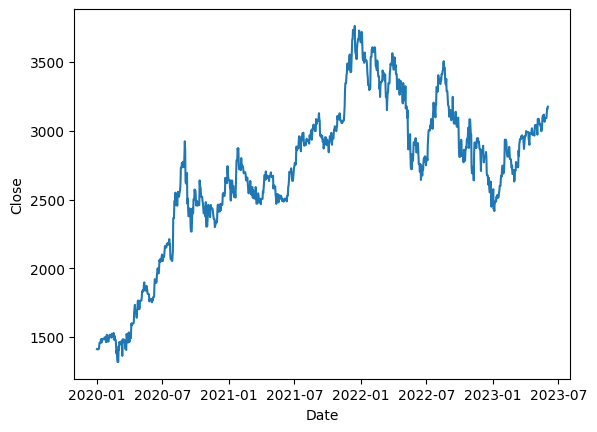

In [13]:
sns.lineplot(data=df,x='Date',y='Close')

In [15]:
df.head()

,Open,Close,High,Low,Volume
Date,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN
2020-01-02,1407.992554,1411.324951,1412.25,1403.839966,30784.0
2020-01-03,1417.500000,1410.000000,1418.75,1406.750000,37728.0
2020-01-04,1417.500000,1410.000000,1418.75,1406.750000,37728.0
2020-01-05,1417.500000,1410.000000,1418.75,1406.750000,37728.0


In [22]:
df['reveniue'] = (df.Close - df.Close.shift(+1))/df.Close.shift(+1)
df['reveniue_log'] = np.log(df.Close/df.Close.shift(+1))

<Axes: ylabel='Density'>

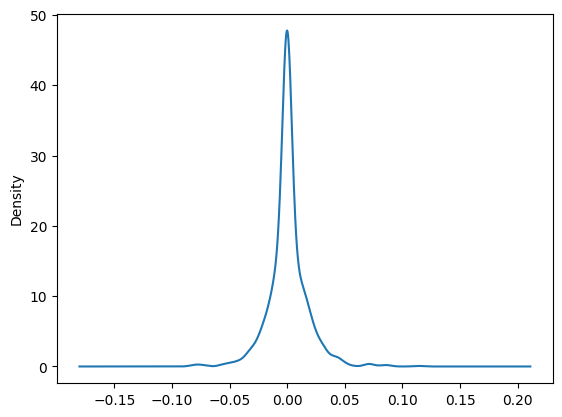

In [23]:
df.reveniue.plot.kde()

<Axes: ylabel='Density'>

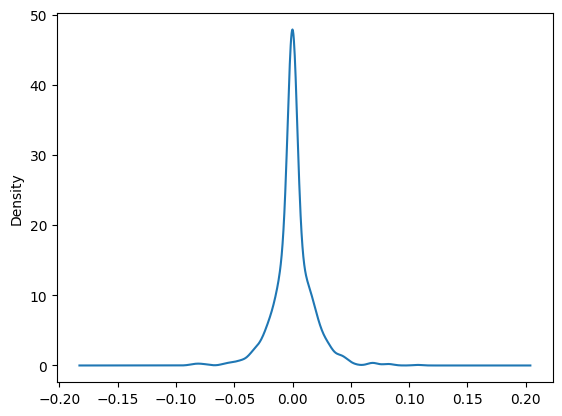

In [24]:
df.reveniue_log.plot.kde()

<Axes: xlabel='Date', ylabel='reveniue'>

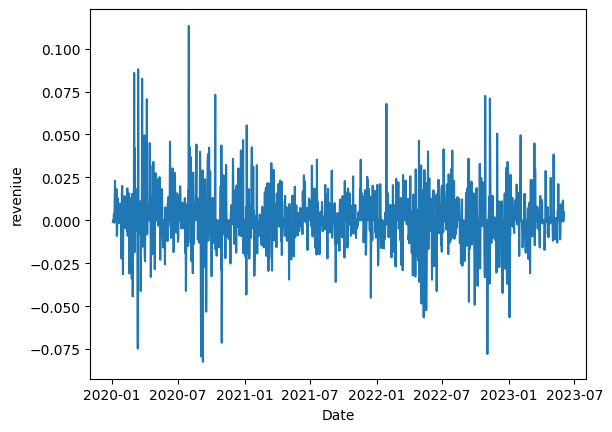

In [27]:
sns.lineplot(data=df,x='Date',y='reveniue')

In [29]:
# rendimiento esperado
100*df.reveniue.mean()

0.07894784206644108

In [40]:
100*df.reveniue.median()

0.0

In [30]:
# volatilidad
np.std(df.reveniue)

0.016712518006861278

In [41]:
2*np.std(df.reveniue)

0.033425036013722556

In [44]:
# anualizada 
np.std(df.reveniue)*np.power(252,0.5)

0.26530299856706285

In [31]:
# coeficiente de variacion
np.std(df.reveniue)/df.reveniue.mean()

21.1690624713926

In [42]:
# Var al 95b y al 99
df.reveniue.describe(percentiles=[0.01,0.025,0.05,0.25,0.95,0.975,0.99])

count    1247.000000
mean        0.000789
std         0.016719
min        -0.082479
1%         -0.044751
2.5%       -0.032967
5%         -0.025100
25%        -0.004760
50%         0.000000
95%         0.028326
97.5%       0.036636
99%         0.048197
max         0.113204
Name: reveniue, dtype: float64

In [36]:
# rendimiento anualizado
# 252 periodos o dias
np.power(1+df.reveniue.mean(),252)-1

0.22002343858799778

In [39]:
252*(1+df.reveniue.mean())

252.19894856200742

In [46]:
agua = clean_data(stocks,'AGUA.MX')
agua.set_index('Date',inplace=True)
agua['reveniue'] = (agua.Close - agua.Close.shift(+1))/agua.Close.shift(+1)
agua['reveniue_log'] = np.log(agua.Close/agua.Close.shift(+1))

In [47]:
agua

,Open,Close,High,Low,Volume,reveniue,reveniue_log
Date,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,16.070000,16.000000,16.490000,15.880000,283416.0,NaN,NaN
2020-01-03,16.000000,15.970000,16.190001,15.890000,104454.0,-0.001875,-0.001877
2020-01-04,16.000000,15.970000,16.190001,15.890000,104454.0,0.000000,0.000000
2020-01-05,16.000000,15.970000,16.190001,15.890000,104454.0,0.000000,0.000000
...,...,...,...,...,...,...,...
2023-05-29,28.690001,28.850000,28.850000,28.299999,98456.0,0.003827,0.003820
2023-05-30,28.629999,27.709999,28.629999,27.299999,240763.0,-0.039515,-0.040317
2023-05-31,27.639999,27.990000,28.590000,26.510000,397457.0,0.010105,0.010054


In [50]:
all_assets = df[['Close','reveniue_log']].rename(columns={'Close':'Close_apple','reveniue_log':'reveniue_log_apple'})

In [53]:
all_assets = all_assets.join(agua[['Close','reveniue_log']].rename(columns={'Close':'Close_agua','reveniue_log':'reveniue_log_agua'}))

In [55]:
all_assets['portafolio_change'] = 0.5*all_assets.reveniue_log_agua + 0.5*all_assets.reveniue_log_apple

In [57]:
all_assets.portafolio_change.describe()

count    1247.000000
mean        0.000539
std         0.015901
min        -0.063314
25%        -0.004448
50%         0.000000
75%         0.006354
max         0.074120
Name: portafolio_change, dtype: float64

In [59]:
amount = 10000

In [60]:
all_assets['var_historic'] = amount*all_assets.portafolio_change

In [64]:
all_assets.var_historic.describe(percentiles=[0.01,0.05,0.95,0.99])

count    1247.000000
mean        5.386127
std       159.014140
min      -633.139127
1%       -471.693057
5%       -257.806380
50%         0.000000
95%       270.451713
99%       490.104031
max       741.198302
Name: var_historic, dtype: float64

In [65]:
# simulacion monte carlo apple

mu = df.reveniue.mean()
sigma = df.reveniue.std()


In [67]:
sigma

0.0167192231297015

0.11741335687320831

In [93]:
monte = [np.random.normal(mu, sigma)for i in range(10000)]

In [101]:
pd.Series(monte).describe(percentiles=[0.95,0.99])

count    10000.000000
mean         0.000516
std          0.016623
min         -0.067580
50%          0.000692
95%          0.027822
99%          0.038152
max          0.063556
dtype: float64

In [102]:
df.reveniue.describe(percentiles=[0.01,0.05,0.95,0.99])

count    1247.000000
mean        0.000789
std         0.016719
min        -0.082479
1%         -0.044751
5%         -0.025100
50%         0.000000
95%         0.028326
99%         0.048197
max         0.113204
Name: reveniue, dtype: float64